In [21]:
# !pip install simple-icd-10
# !pip install seaborn

In [1]:
import os
import pandas as pd
import json
import re
import simple_icd_10 as icd
from tqdm import tqdm
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 1000)

In [2]:
# MODEL = "qwen3-235b-a22b"
# MODEL = "GPT_OSS_MODEL_SIZE.BIG_Low"
MODEL = "GPT_OSS_MODEL_SIZE.SMALL_Low"
ICD_CODES = ["C61", "C34", "C50", "C25", "C22", "C18", "C64", "C80", "C83", "C91"]
TRY = 0
RESPONSES_PATH = "outputs_mcq/responses_{MODEL}_{ICD_CODE}_{TRY}.tsv"

In [3]:
responses = [
    pd.read_csv(
        RESPONSES_PATH.format(MODEL=MODEL, ICD_CODE=ICD_CODE, TRY=TRY), 
        sep="\t"
    ).drop(columns=["Unnamed: 0"], errors="ignore")
    for ICD_CODE in ICD_CODES
]
responses = pd.concat(responses, axis=0)

In [4]:
responses.shape

(33920, 3)

In [5]:
responses.count()

icd10_category_1    33920
icd10_category_2    33920
response            33920
dtype: int64

In [6]:
responses.head()

,icd10_category_1,icd10_category_2,response
0,C61,K76,B
1,C61,R18,B
2,C61,K74,B
3,C61,B19,B
4,C61,J44,B


### Regularization

In [7]:
responses["response"].value_counts().index.tolist()

['B', 'A', '[B]']

In [8]:
responses["response"] = responses["response"].apply(lambda x: "B" if x == "[B]" else x)

In [14]:
N_ALL_CODES = len(responses)//2//len(ICD_CODES)
print(N_ALL_CODES)
assert responses['icd10_category_1'].value_counts()['C61'] == N_ALL_CODES + len(ICD_CODES)
assert responses['icd10_category_2'].value_counts()['C61'] == N_ALL_CODES + len(ICD_CODES)
assert set(responses["response"].value_counts().index.tolist()) == set(["A", "B"])

1696


In [15]:
responses["score"] = responses["response"].map({"A": 1, "B": 0})

### Getting probs

In [19]:
def extract_indexes(input_list, N, forward=True):
    K = len(input_list) // N // 2
    result = []
    for i in range(K):
        start_index = 2 * i * N if forward else 2 * i * N + N
        end_index = start_index + N
        result.extend(input_list[start_index:end_index])
    return result

forward_indexes = extract_indexes(np.arange(len(responses)), N_ALL_CODES)
backward_indexes = extract_indexes(np.arange(len(responses)), N_ALL_CODES, forward=False)
    
probs = responses[["icd10_category_1", "icd10_category_2", "score"]].iloc[forward_indexes].copy(deep=True)
probs = pd.merge(
    probs,
    responses[["icd10_category_1", "icd10_category_2", "score"]].iloc[backward_indexes],
    how="inner",
    left_on=["icd10_category_1", "icd10_category_2"],
    right_on=["icd10_category_2", "icd10_category_1"],
    suffixes=("_forward", "_backward"),
)
assert len(probs) == N_ALL_CODES*len(ICD_CODES)

In [20]:
probs.shape

(16960, 6)

In [21]:
probs.head(2)

,icd10_category_1_forward,icd10_category_2_forward,score_forward,icd10_category_1_backward,icd10_category_2_backward,score_backward
0,C61,K76,0,K76,C61,0
1,C61,R18,0,R18,C61,0


In [22]:
probs.rename(columns={"icd10_category_1_forward": "icd10_category_1", "icd10_category_2_forward": "icd10_category_2"}, inplace=True)
probs.drop(columns=["icd10_category_1_backward", "icd10_category_2_backward"], inplace=True)
probs['score'] = probs[['score_forward', 'score_backward']].mean(axis=1)
probs.drop(columns=['score_forward', 'score_backward'], inplace=True)

In [23]:
probs.head(2)

,icd10_category_1,icd10_category_2,score
0,C61,K76,0.0
1,C61,R18,0.0


In [24]:
probs['score'].value_counts()

score
0.0    16164
0.5      747
1.0       49
Name: count, dtype: int64

<Axes: >

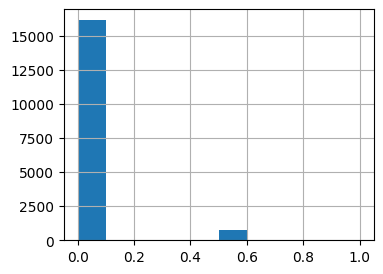

In [25]:
probs['score'].hist(figsize=(4, 3), bins=np.arange(0, 1.1, 0.1))

In [27]:
if not os.path.exists("scores_mcq/"): os.makedirs("scores_mcq/")
probs.to_csv(f"scores_mcq/scores_{MODEL}_{','.join(ICD_CODES)}_{TRY}.csv")